# Data Preparation for Tonal Sentiment Analysis
#### From DaBloat (Villamor, Kurt Russel A.)

- MELD is a Dataset from the Friends TV Show
- This version of MELD I got is in mp4 format which is in video. I would like to use the audio files of it and save it as .wav files for high quality audio

In [3]:
# Some of the Important Libraries
import subprocess
from glob import glob
import os
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
import torchaudio
import torchaudio.transforms as T
import torchaudio.functional as F
import librosa
import matplotlib.pyplot as plt

In [4]:
# Example Video From the Dataset
from IPython.display import Video, Audio

Video(data="MELD.Raw/train_splits/dia0_utt0.mp4")

# MP4 to WAV Conversion of Training Dataset

In [5]:
# From mp4 to .wav files
sample_rate = 16000

for item in glob('MELD.Raw/train_splits/*.mp4'):
    wheres = item
    tos = "MELD.Wav/train/" + item.split('/')[-1].split('.')[0] + '.wav'
    print(wheres, tos)
    

    command = [
                'ffmpeg',
                '-i', wheres,
                '-ar', str(sample_rate),  # resample to 16kHz
                '-ac', '1',               # mono channel
                '-loglevel', 'error',
                tos
            ]
    subprocess.run(command)

MELD.Raw/train_splits/dia202_utt15.mp4 MELD.Wav/train/dia202_utt15.wav


File 'MELD.Wav/train/dia202_utt15.wav' already exists. Overwrite? [y/N] 

KeyboardInterrupt: 

In [6]:
Audio('MELD.Wav/train/dia0_utt0.wav')

- since the MELD has annotations, we will use that for easier applications
- Using Pytorch, let's Build the dataset by transforming the raw wav files to MFCC (Mel-Frequency Cepstral Coefficients)
- In this part, This Dataset is Created to be applicable to a basic Bi-LTSM model

In [7]:
# This is also Present in the dataset.py
class MFCCData(Dataset):
    def __init__(self, data, aud, label, max_len=300):
        self.data = pd.read_csv(data)
        self.audio_files = aud
        self.label_map = label
        self.sample_rate = 16000
        self.max_len = max_len
        
        self.to_mfcc = T.MFCC(
            n_mfcc = 40,
            sample_rate = self.sample_rate,
            melkwargs={
                "n_fft": 400,
                "hop_length": 160,
                "n_mels": 64,
                "center": True,
                "power": 2.0
            }
        )
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, index):
        row = self.data.iloc[index]
        wav = os.path.join(self.audio_files, f'dia{row['Dialogue_ID']}_utt{row['Utterance_ID']}' + '.wav')
        label = self.label_map[row['Emotion']]
        
        wave, sr = torchaudio.load(wav)
        mfcc = self.to_mfcc(wave).squeeze(0).transpose(0,1)
              
        T_current, D = mfcc.shape
        if T_current < self.max_len:
            pad = torch.zeros(self.max_len - T_current, D)
            mfcc = torch.cat([mfcc, pad], dim=0)
        else:
            mfcc = mfcc[:self.max_len, :]
        
        return mfcc, torch.tensor(label)
        

- since the dataset's annotation give 7 emotions (neutral, joy, surprise, sadness, anger, disgust, fear) I need to compress this one to 3 sentiments since my partner has only 3 {positive, neutral, negative}

In [8]:
labels_map = {
    "neutral": 0,
    'joy': 1,
    "surprise": 1,
    'sadness': 2,
    'anger': 2,
    'disgust': 2,
    'fear': 2
}

In [9]:
sentiment = {
    0 : 'neutral',
    1 : 'positive',
    2 : 'negative'
}

In [10]:
# For samples for MFCC dataset
dataset = MFCCData(data='MELD.Raw/train_sent_emo.csv', aud="MELD.Wav/train", label=labels_map)

In [11]:
# dataloader
load = DataLoader(dataset, batch_size=32, shuffle=True)

In [12]:
# Text form the Example Earlier 
load.dataset.data['Utterance'][0]

'also I was the point person on my company\x92s transition from the KL-5 to GR-6 system.'

In [13]:
# Torchaudio Visualization Tutorial
def plot_spectrogram(specgram, title=None, ylabel="freq_bin", ax=None):
    if ax is None:
        _, ax = plt.subplots(1, 1)
    if title is not None:
        ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.imshow(librosa.power_to_db(specgram), origin="lower", aspect="auto", interpolation="nearest")
    plt.show()

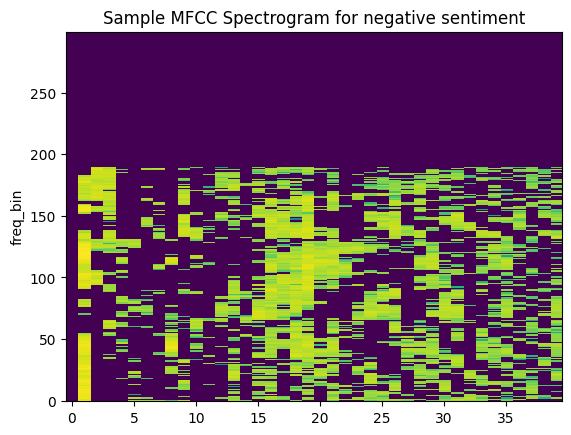

torch.Size([32, 300, 40])
tensor(2)


In [14]:
for inputs, labels, in load:
    plot_spectrogram(inputs[0], title=f"Sample MFCC Spectrogram for {sentiment[labels[0].item()]} sentiment")
    print(inputs.shape)
    print(labels[0])
    break

In [15]:
# Created by DaBloat